# Notebook 05 — So sánh mô hình và Phân tích sai số

**Mục đích:** So sánh toàn diện ARIMA và Random Forest, phân tích sai số và đề xuất hướng ứng dụng.

**Đầu vào:**
- `data/processed/clean_data.csv`
- `results/arima_predictions.csv`
- `results/rf_predictions.csv`

**Đầu ra:**
- `results/model_comparison.csv`
- Biểu đồ so sánh tại `figures/`


In [1]:
import sys
from pathlib import Path
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_processor import load_clean, split_train_test
from src.evaluator import compare_models, naive_forecast, error_analysis
from src.visualizer import plot_forecast_vs_actual, plot_monthly_error
from src.config import TARGET_COL, ARIMA_PRED_PATH, RF_PRED_PATH

print('✅ Import thành công')

✅ Import thành công


## 1. Nạp dữ liệu thực tế và kết quả dự báo

In [2]:
df = load_clean()
_, test = split_train_test(df)
actual = test[TARGET_COL]

arima_preds = pd.read_csv(ARIMA_PRED_PATH, index_col=0, parse_dates=True).squeeze()
rf_preds    = pd.read_csv(RF_PRED_PATH,    index_col=0, parse_dates=True).squeeze()
naive_preds = naive_forecast(actual)

print(f'Tập kiểm thử: {len(actual)} ngày')
print(f'ARIMA dự báo: {len(arima_preds)} ngày')
print(f'RF dự báo:    {len(rf_preds)} ngày')

2026-08-05 20:49:08,312 [INFO] Tập huấn luyện: 1,084 ngày (2022-01-13 → 2024-12-31)
2026-08-05 20:49:08,313 [INFO] Tập kiểm thử:   181 ngày (2025-01-01 → 2025-06-30)


Tập kiểm thử: 181 ngày
ARIMA dự báo: 181 ngày
RF dự báo:    181 ngày


## 2. Bảng so sánh tổng hợp (MAE, RMSE, R²)

In [3]:
comparison = compare_models(
    actual=actual,
    predictions={
        'Dự báo tham chiếu': naive_preds,
        'ARIMA':             arima_preds,
        'Random Forest':     rf_preds,
    },
    save=True
)
display(comparison)

2026-08-05 20:49:08,357 [INFO] [Dự báo tham chiếu] MAE=16.8090 | RMSE=22.3952 | R²=0.4203
2026-08-05 20:49:08,360 [INFO] [ARIMA] MAE=16.9461 | RMSE=22.5466 | R²=0.4313
2026-08-05 20:49:08,362 [INFO] [Random Forest] MAE=15.8635 | RMSE=21.2432 | R²=0.4951
2026-08-05 20:49:08,365 [INFO] Đã lưu bảng so sánh tại: D:\DuAn\QuanLyBuiMinPM25\results\model_comparison.csv


,MAE,RMSE,R²,Cải thiện RMSE (%)
Mô hình,,,,
Dự báo tham chiếu,16.8090,22.3952,0.4203,0.00
ARIMA,16.9461,22.5466,0.4313,-0.68
Random Forest,15.8635,21.2432,0.4951,5.14


## 3. Biểu đồ so sánh cả 3 phương pháp

2026-08-05 20:49:08,567 [INFO] Đã lưu biểu đồ: D:\DuAn\QuanLyBuiMinPM25\figures\11_all_models_comparison.png


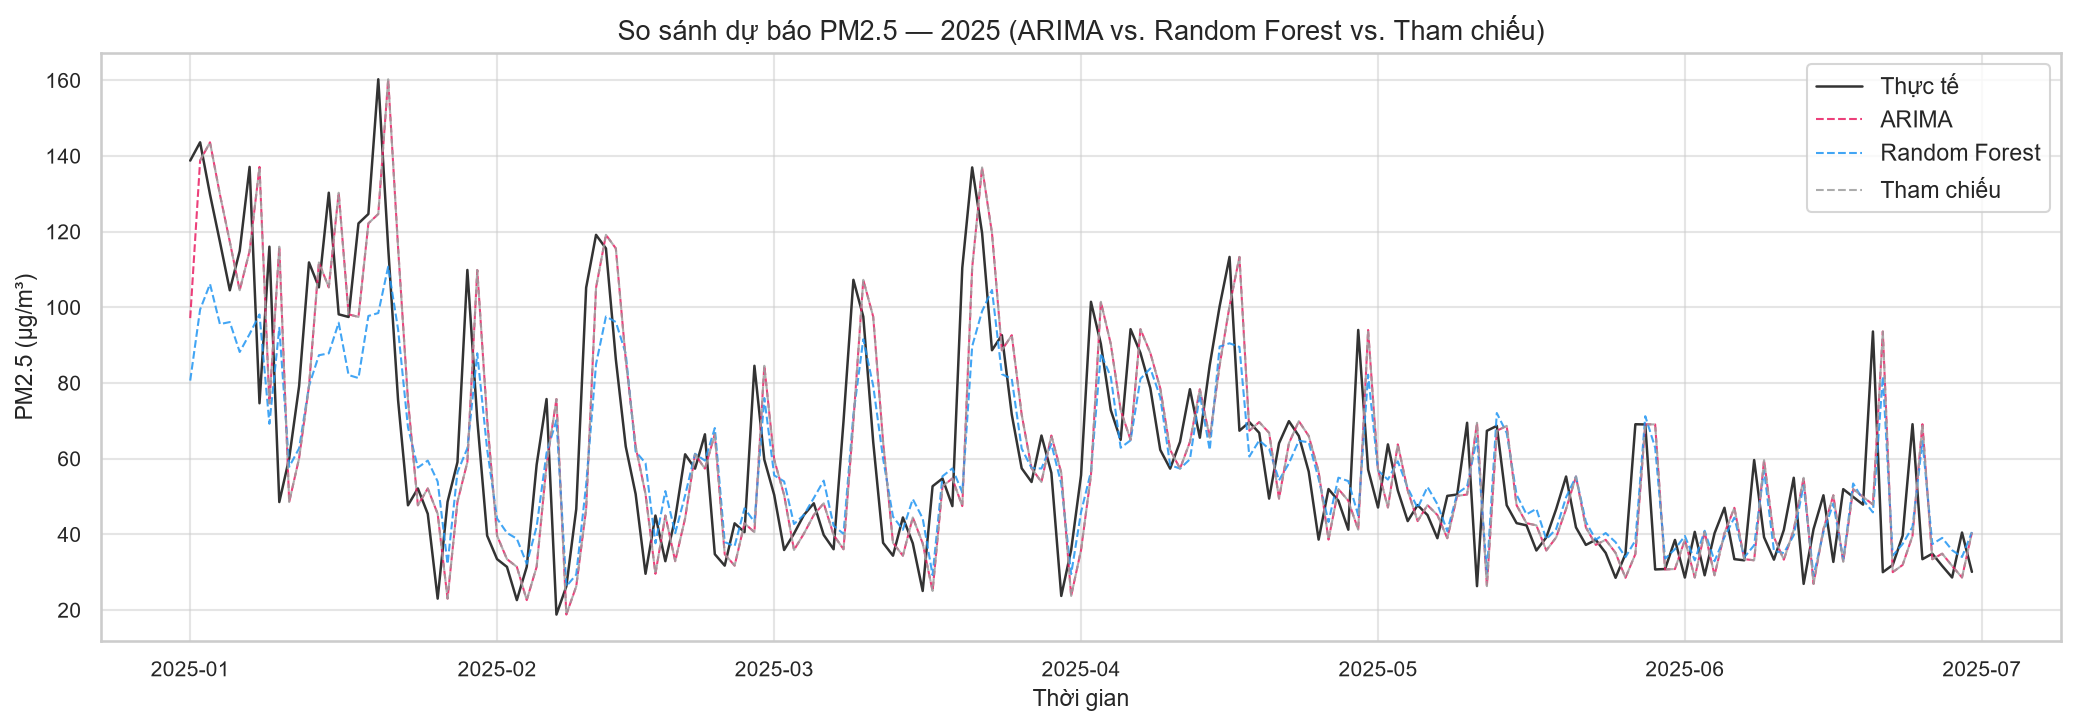

In [4]:
fig = plot_forecast_vs_actual(
    actual=actual,
    preds={
        'ARIMA':         arima_preds,
        'Random Forest': rf_preds,
        'Tham chiếu':    naive_preds,
    },
    title='So sánh dự báo PM2.5 — 2025 (ARIMA vs. Random Forest vs. Tham chiếu)',
    filename='11_all_models_comparison'
)
plt.show()

## 4. Phân tích sai số theo tháng

2026-08-05 20:49:08,823 [INFO] Đã lưu biểu đồ: D:\DuAn\QuanLyBuiMinPM25\figures\12_arima_monthly_error.png


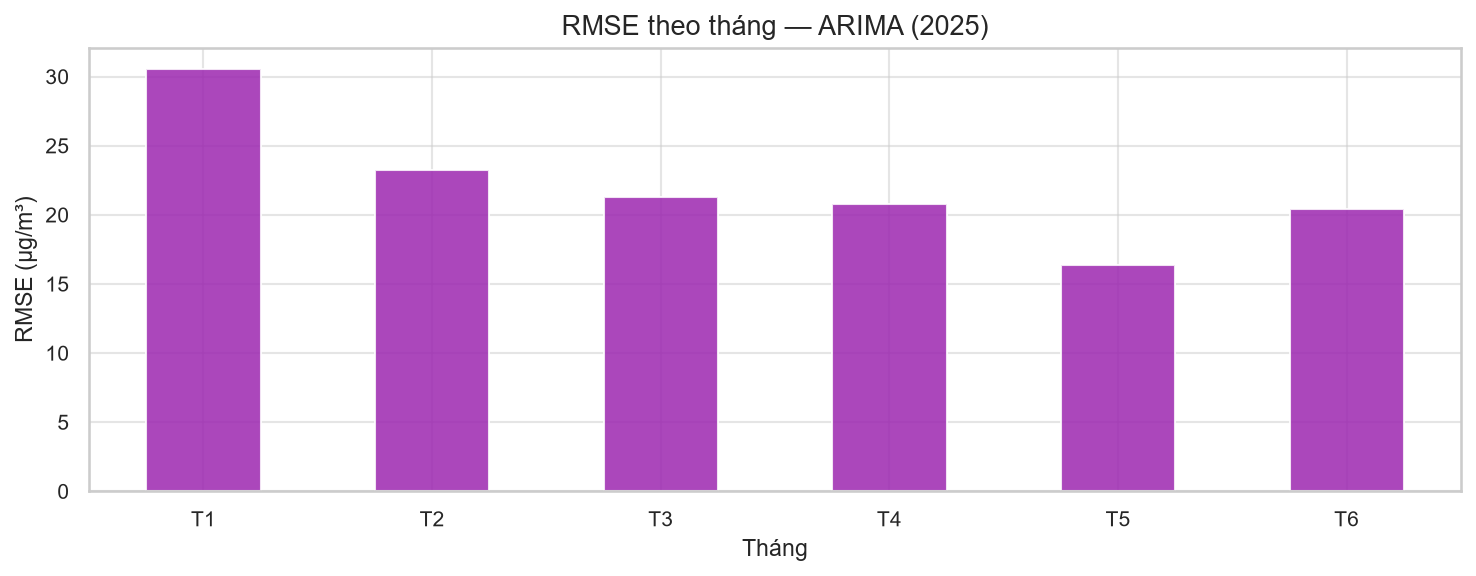

2026-08-05 20:49:08,965 [INFO] Đã lưu biểu đồ: D:\DuAn\QuanLyBuiMinPM25\figures\13_rf_monthly_error.png


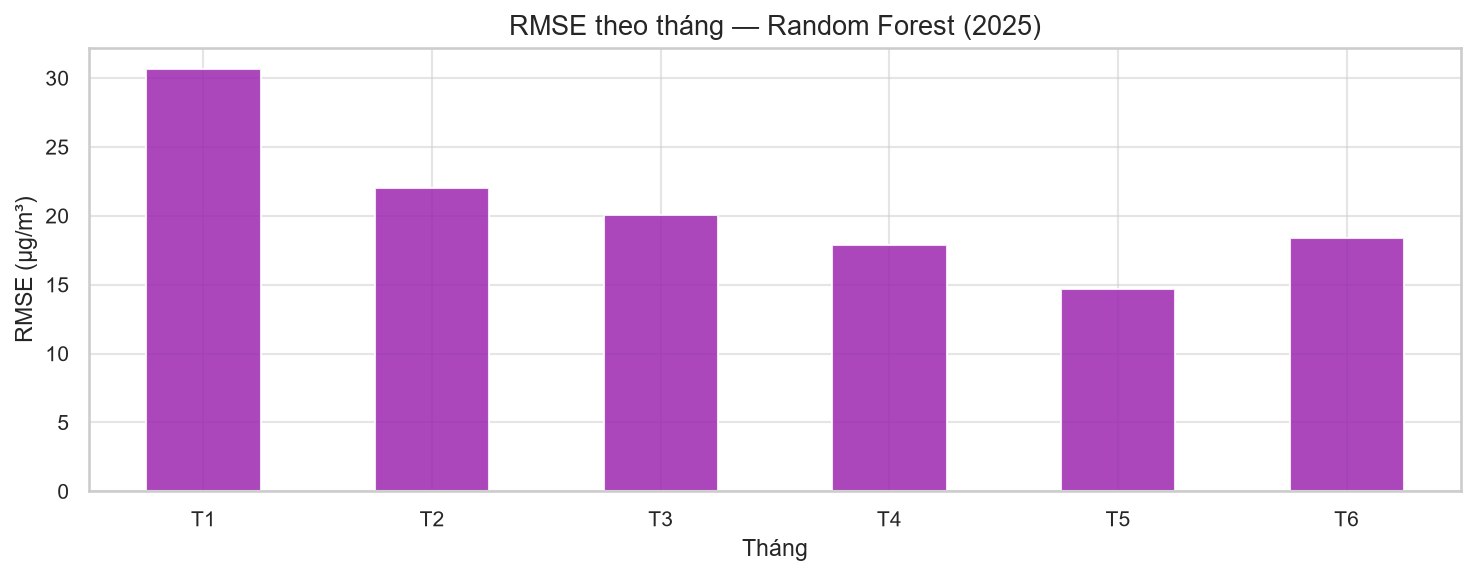

In [5]:
fig_arima = plot_monthly_error(actual, arima_preds, model_name='ARIMA',
                               filename='12_arima_monthly_error')
plt.show()

fig_rf = plot_monthly_error(actual, rf_preds, model_name='Random Forest',
                             filename='13_rf_monthly_error')
plt.show()

## 5. Top 10 ngày sai số lớn nhất

In [6]:
print('=== ARIMA — Top 10 ngày sai số lớn nhất ===')
top_arima = error_analysis(actual, arima_preds, model_name='ARIMA', top_n=10)
display(top_arima.round(2))

print('\n=== Random Forest — Top 10 ngày sai số lớn nhất ===')
top_rf = error_analysis(actual, rf_preds, model_name='Random Forest', top_n=10)
display(top_rf.round(2))

2026-08-05 20:49:09,046 [INFO] [ARIMA] Top 10 ngày sai số lớn nhất:
2026-08-05 20:49:09,049 [INFO]                Thực tế      Dự báo  Sai số tuyệt đối  Sai số tương đối (%)
date                                                                      
2025-01-10   48.548750  116.041667         67.492917                139.02
2025-06-21   30.013750   93.625000         63.611250                211.94
2025-03-20  110.457917   47.472500         62.985417                 57.02
2025-01-08   74.652917  137.125417         62.472500                 83.68
2025-02-10  105.201667   46.687500         58.514167                 55.62
2025-02-07   18.812500   75.770417         56.957917                302.77
2025-04-29   94.027917   41.236250         52.791667                 56.14
2025-01-29  109.882083   59.104167         50.777917                 46.21
2025-04-17   67.402917  113.333333         45.930417                 68.14
2025-04-02  101.472083   55.652500         45.819583                 45.15


=== ARIMA — Top 10 ngày sai số lớn nhất ===


,Thực tế,Dự báo,Sai số tuyệt đối,Sai số tương đối (%)
date,,,,
2025-01-10,48.55,116.04,67.49,139.02
2025-06-21,30.01,93.62,63.61,211.94
2025-03-20,110.46,47.47,62.99,57.02
2025-01-08,74.65,137.13,62.47,83.68
2025-02-10,105.20,46.69,58.51,55.62
2025-02-07,18.81,75.77,56.96,302.77
2025-04-29,94.03,41.24,52.79,56.14
2025-01-29,109.88,59.10,50.78,46.21
2025-04-17,67.40,113.33,45.93,68.14


2026-08-05 20:49:09,054 [INFO] [Random Forest] Top 10 ngày sai số lớn nhất:
2026-08-05 20:49:09,056 [INFO]                Thực tế     Dự báo  Sai số tuyệt đối  Sai số tương đối (%)
date                                                                     
2025-01-20  160.285000  98.502955         61.782045                 38.55
2025-03-20  110.457917  51.075390         59.382527                 53.76
2025-01-01  138.791667  80.651099         58.140567                 41.89
2025-02-10  105.201667  53.144460         52.057206                 49.48
2025-06-21   30.013750  81.724358         51.710608                172.29
2025-02-07   18.812500  70.204870         51.392370                273.18
2025-04-29   94.027917  45.017517         49.010400                 52.12
2025-06-20   93.625000  45.817887         47.807113                 51.06
2025-03-21  136.986250  89.722244         47.264006                 34.50
2025-01-29  109.882083  62.764555         47.117528                 42.88



=== Random Forest — Top 10 ngày sai số lớn nhất ===


,Thực tế,Dự báo,Sai số tuyệt đối,Sai số tương đối (%)
date,,,,
2025-01-20,160.28,98.50,61.78,38.55
2025-03-20,110.46,51.08,59.38,53.76
2025-01-01,138.79,80.65,58.14,41.89
2025-02-10,105.20,53.14,52.06,49.48
2025-06-21,30.01,81.72,51.71,172.29
2025-02-07,18.81,70.20,51.39,273.18
2025-04-29,94.03,45.02,49.01,52.12
2025-06-20,93.62,45.82,47.81,51.06
2025-03-21,136.99,89.72,47.26,34.50


## 6. Biểu đồ sai số tuyệt đối theo thời gian

2026-08-05 20:49:09,294 [INFO] Đã lưu biểu đồ: D:\DuAn\QuanLyBuiMinPM25\figures\14_absolute_errors.png


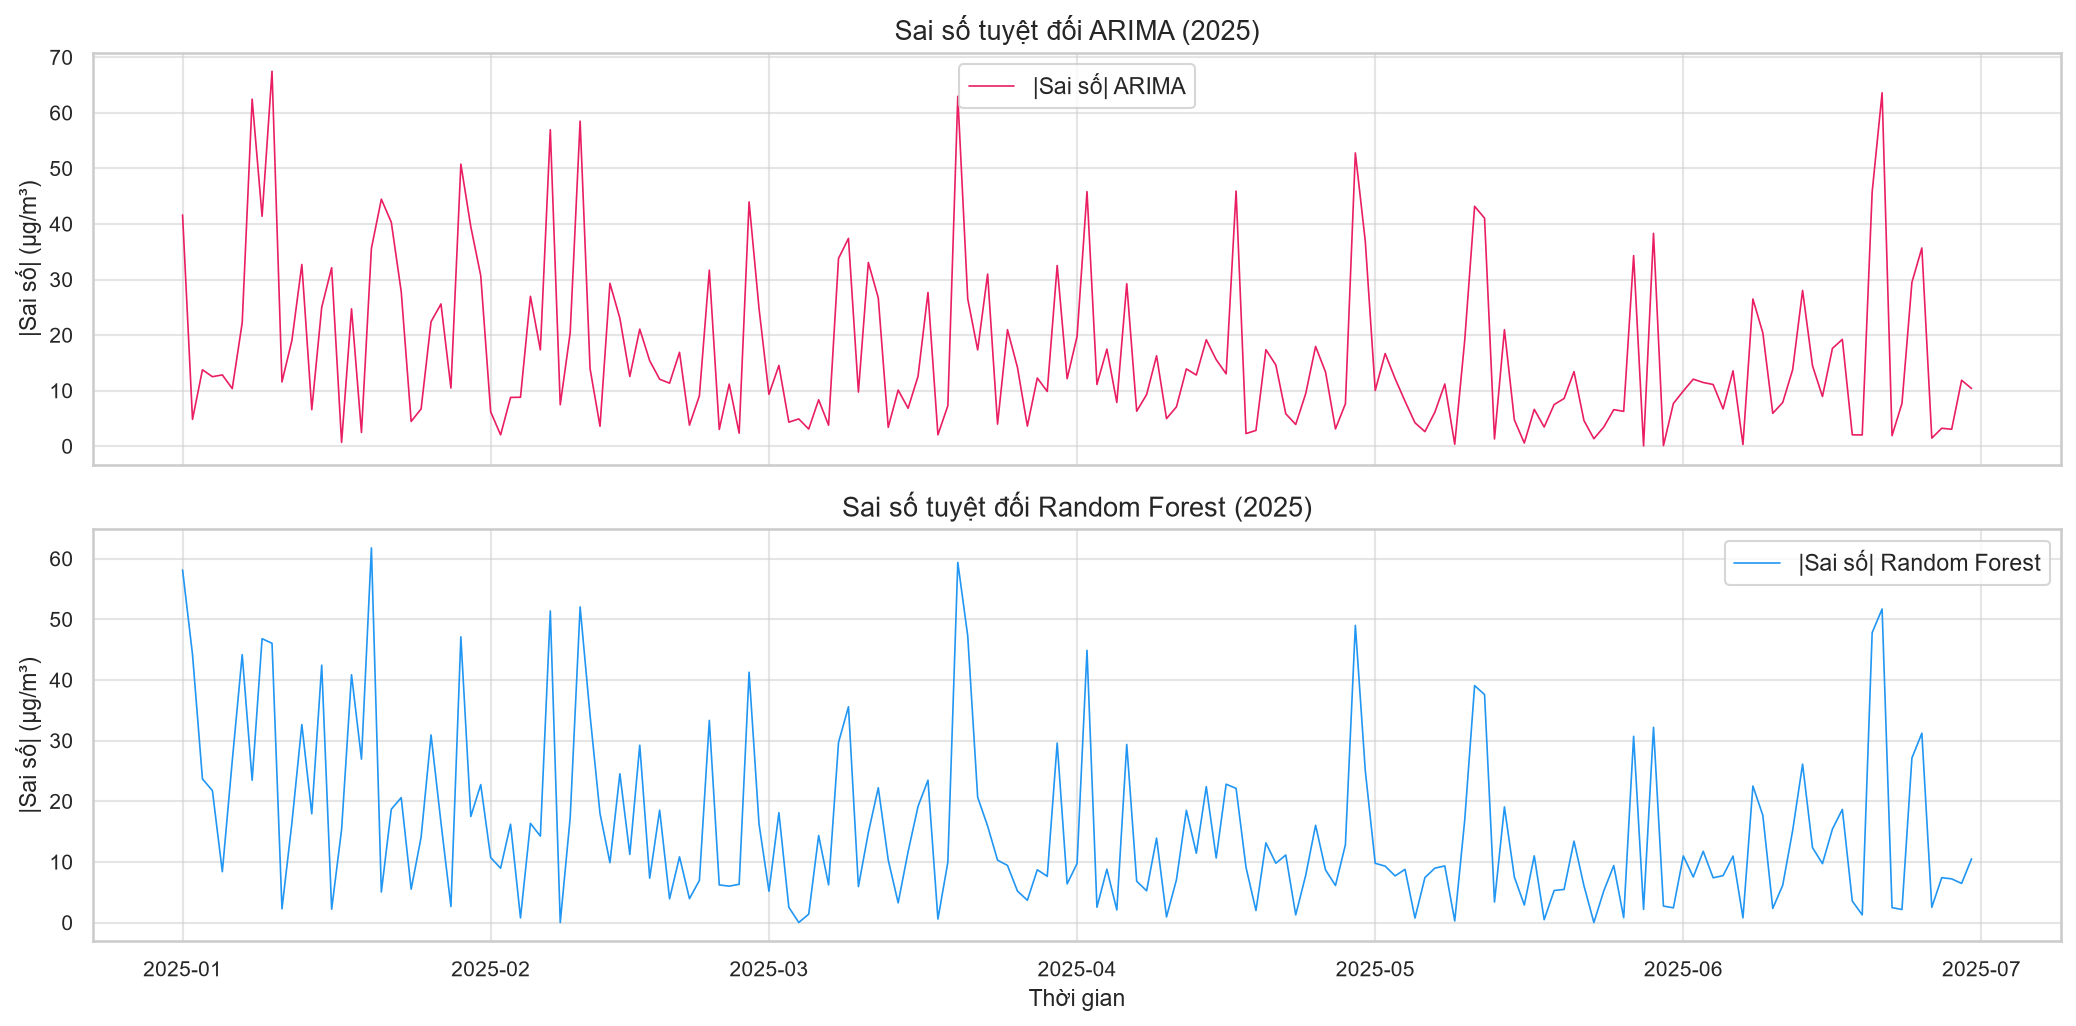

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot((actual - arima_preds).abs(), color='#E91E63', linewidth=0.8, label='|Sai số| ARIMA')
axes[0].set_title('Sai số tuyệt đối ARIMA (2025)')
axes[0].set_ylabel('|Sai số| (μg/m³)')
axes[0].legend()

axes[1].plot((actual - rf_preds).abs(), color='#2196F3', linewidth=0.8, label='|Sai số| Random Forest')
axes[1].set_title('Sai số tuyệt đối Random Forest (2025)')
axes[1].set_ylabel('|Sai số| (μg/m³)')
axes[1].set_xlabel('Thời gian')
axes[1].legend()

plt.tight_layout()
from src.visualizer import _save
_save(fig, '14_absolute_errors')
plt.show()

## 7. Tổng kết và Kết luận

**Điền thông tin sau khi chạy xong các cell trên:**


In [8]:
print('=== KẾT QUẢ TỔNG HỢP ===')
display(comparison)

best_model = comparison['RMSE'].idxmin()
print(f'\n✅ Mô hình tốt nhất theo RMSE: {best_model}')

arima_row = comparison.loc['ARIMA'] if 'ARIMA' in comparison.index else None
rf_row    = comparison.loc['Random Forest'] if 'Random Forest' in comparison.index else None

if arima_row is not None and rf_row is not None:
    improvement = (arima_row['RMSE'] - rf_row['RMSE']) / arima_row['RMSE'] * 100
    print(f'Random Forest cải thiện RMSE so với ARIMA: {improvement:.2f}%')
    print(f'\nKết luận: Trong phạm vi bộ dữ liệu này, {best_model} cho kết quả dự báo tốt hơn.')

=== KẾT QUẢ TỔNG HỢP ===


,MAE,RMSE,R²,Cải thiện RMSE (%)
Mô hình,,,,
Dự báo tham chiếu,16.8090,22.3952,0.4203,0.00
ARIMA,16.9461,22.5466,0.4313,-0.68
Random Forest,15.8635,21.2432,0.4951,5.14



✅ Mô hình tốt nhất theo RMSE: Random Forest
Random Forest cải thiện RMSE so với ARIMA: 5.78%

Kết luận: Trong phạm vi bộ dữ liệu này, Random Forest cho kết quả dự báo tốt hơn.


---
✅ **Hoàn thành toàn bộ pipeline phân tích và dự báo PM2.5 Hà Nội!**

Kết quả đã lưu tại:
- `results/model_comparison.csv` — Bảng so sánh MAE, RMSE, R²
- `results/arima_predictions.csv` — Kết quả dự báo ARIMA
- `results/rf_predictions.csv` — Kết quả dự báo Random Forest
- `figures/` — Toàn bộ biểu đồ